# Notebook 6: Graph Attention Network (GAT)

**Why GAT?** Attention weights let the model focus on the most relevant neighbors — useful for identifying suspicious connections in fraud graphs.

In [1]:
import sys
sys.path.append('../src')

import torch
import matplotlib.pyplot as plt

from graph_builder import load_graph
from models import GAT
from train import train_model
from evaluate import evaluate_model, plot_confusion_matrix, plot_roc_curve, plot_pr_curve, plot_training_history
from utils import set_seed, get_device, save_model

set_seed(42)
device = get_device()
print('Device:', device)
%matplotlib inline

C:\Users\anmol\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\anmol\AppData\Local\Programs\Python\Python310\Lib\site-packages\torch_scatter\_version_cpu.pyd
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
C:\Users\anmol\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\anmol\AppData\Local\Programs\Python\Python310\Lib\site-packages\torch_sparse\_version_cpu.pyd
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


Device: cpu


In [2]:
data = load_graph('../data/processed')
print(data)

Data(x=[46564, 166], edge_index=[2, 36624], y=[46564], train_mask=[46564], val_mask=[46564], test_mask=[46564])


## 1. Model Definition

In [3]:
model = GAT(input_dim=data.num_features, hidden_dim=32, output_dim=2, heads=4, dropout=0.4)
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

GAT(
  (gat1): GATConv(166, 32, heads=4)
  (gat2): GATConv(128, 2, heads=1)
)
Total parameters: 21,894


## 2. Training

Epoch  20 | Train Loss: 0.4953 | Val Loss: 0.3822


Epoch  40 | Train Loss: 0.4497 | Val Loss: 0.3433


Epoch  60 | Train Loss: 0.4257 | Val Loss: 0.3090


Epoch  80 | Train Loss: 0.4116 | Val Loss: 0.2925


Epoch 100 | Train Loss: 0.3930 | Val Loss: 0.2713


Epoch 120 | Train Loss: 0.3840 | Val Loss: 0.2661


Epoch 140 | Train Loss: 0.3794 | Val Loss: 0.2514


Epoch 160 | Train Loss: 0.3803 | Val Loss: 0.2493


Epoch 180 | Train Loss: 0.3697 | Val Loss: 0.2339


Epoch 200 | Train Loss: 0.3696 | Val Loss: 0.2407


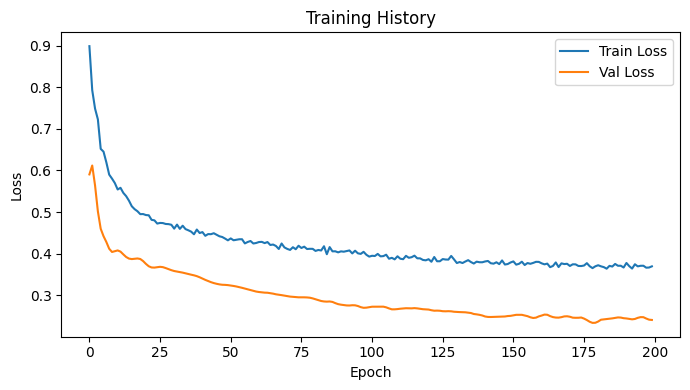

In [4]:
model, history = train_model(
    model, data,
    epochs=200, lr=0.005, weight_decay=5e-4,
    use_class_weights=True, device=device
)
plot_training_history(history, save_path='../results/figures/gat_training_history.png')

## 3. Evaluation

In [5]:
results = evaluate_model(model, data, data.test_mask, device=device)

              precision    recall  f1-score   support

       Licit       0.99      0.87      0.93      8404
     Illicit       0.43      0.95      0.60       909

    accuracy                           0.87      9313
   macro avg       0.71      0.91      0.76      9313
weighted avg       0.94      0.87      0.89      9313

ROC-AUC : 0.9759
PR-AUC  : 0.8681


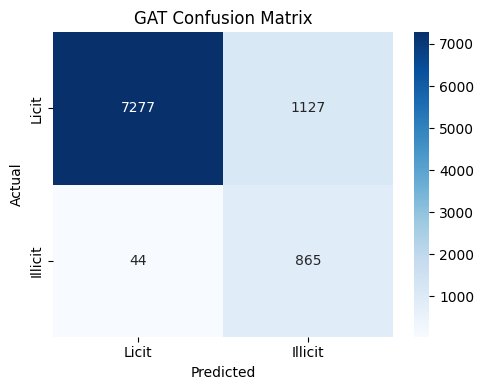

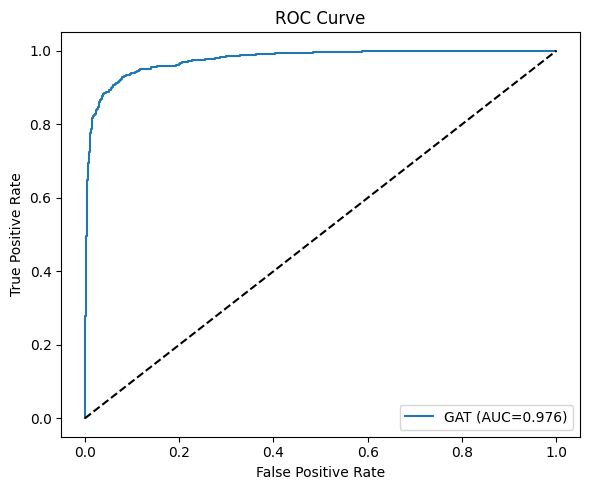

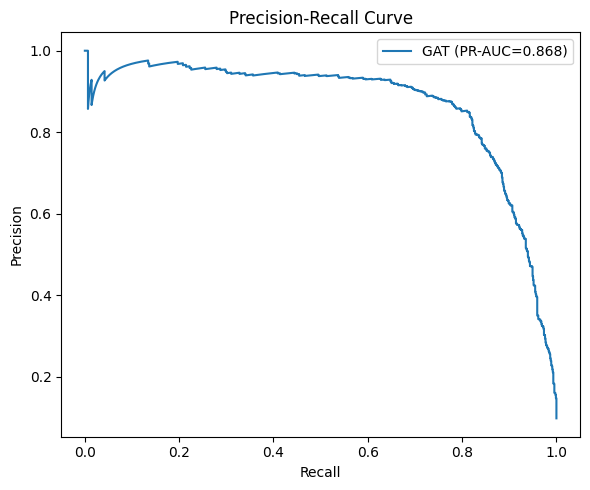

In [6]:
plot_confusion_matrix(results['y_true'], results['y_pred'],
                      title='GAT Confusion Matrix',
                      save_path='../results/confusion_matrices/gat_cm.png')
plot_roc_curve(results['y_true'], results['y_prob'], label='GAT',
               save_path='../results/figures/gat_roc.png')
plot_pr_curve(results['y_true'], results['y_prob'], label='GAT',
              save_path='../results/figures/gat_pr.png')

## 4. Save Model

In [7]:
save_model(model, '../models/gat_model.pt')

Model saved to ../models/gat_model.pt
